# Scatterplot

Ayuda a ver correlación

<Axes: xlabel='skill_count', ylabel='skill_pay'>

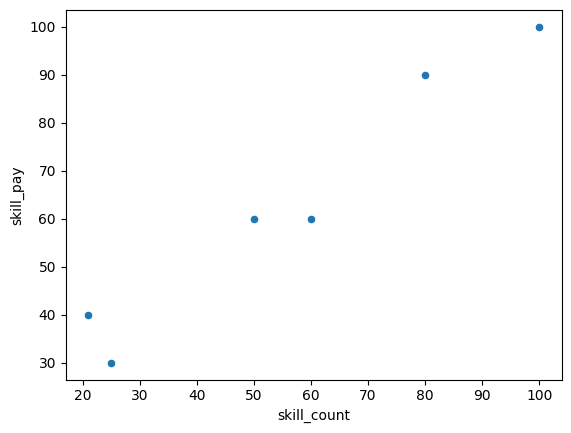

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
data = {
    "job_skills": ["python", "sql", "java", "c++", "c#", "javascript"],
    "skill_count": [100, 80, 50, 21, 25, 60],
    "skill_pay": [100, 90, 60, 40, 30, 60]
}

df = pd.DataFrame(data)
df.plot(kind="scatter", x="skill_count", y="skill_pay")

#Ej real

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast

ds = load_dataset("lukebarousse/data_jobs")
df = ds["train"].to_pandas()

def literal_eval(cadena):
  if cadena and type(cadena) == str:
    return ast.literal_eval(cadena)
  return cadena

df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(literal_eval)

df.sort_values(by="job_posted_date", inplace = True)


In [63]:
df= df[df["job_title_short"]=="Data Analyst"]

In [64]:
df_exploded = df.explode("job_skills")

In [65]:
skill_stats = df_exploded.groupby("job_skills").agg(
    skill_count = ("job_skills", "count"),
    skill_pay = ("salary_year_avg", "median")
)

scatter_table =skill_stats.sort_values(by="skill_count", ascending=False).head(10)
scatter_table

,skill_count,skill_pay
job_skills,,
sql,92428,92500.0
excel,66860,84479.0
python,57190,98500.0
tableau,46455,95000.0
power bi,39380,90000.0
r,29996,92527.5
sas,27998,90000.0
powerpoint,13822,85000.0
word,13562,80000.0


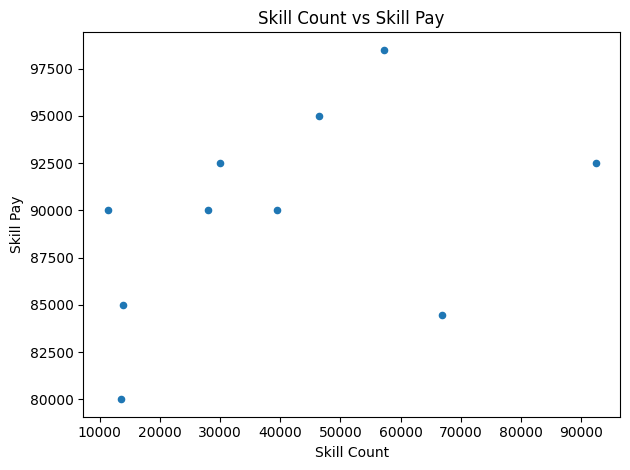

In [66]:
scatter_table.plot(kind="scatter", x = "skill_count", y = "skill_pay")
plt.xlabel("Skill Count")
plt.ylabel("Skill Pay")
plt.title("Skill Count vs Skill Pay")
plt.tight_layout()

plt.show()

/tmp/ipykernel_5119/2855513800.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(txt, (scatter_table["skill_count"][i]+1000, scatter_table["skill_pay"][i]))


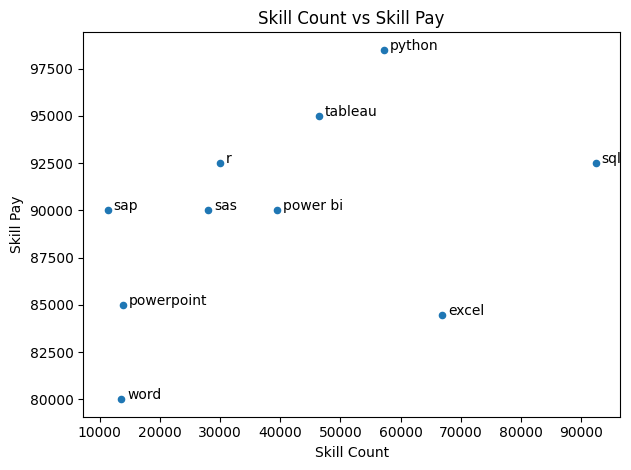

In [67]:
# No es fácil decirle a matplotlib que muestre los nombres, se puede usar annotate o text(coordenadax, coordenaday, texto)

scatter_table.plot(kind="scatter", x = "skill_count", y = "skill_pay")
plt.xlabel("Skill Count")
plt.ylabel("Skill Pay")
plt.title("Skill Count vs Skill Pay")
plt.tight_layout()

for i, txt in enumerate(scatter_table.index):
  plt.annotate(txt, (scatter_table["skill_count"][i]+1000, scatter_table["skill_pay"][i]))

# for i, txt in enumerate(scatter_table.index):
#   plt.text(scatter_table["skill_count"][i]+1000, scatter_table["skill_pay"][i], txt)

plt.show()